# Lab 12: Breaking the O(n^2) Barrier — Analysis

In this notebook you'll visualize how advanced sorting algorithms work, measure their performance against the simple sorts from Lab 11, and discover quicksort's weakness.

**Before you start:** Paste your completed sort functions into the cell below.

In [1]:
# ── TODO 1: Shell Sort — Gap Insertion Sort ───────────────────────


def _gap_insertion_sort(a_list, start, gap):
    """
    Perform insertion sort on a sublist defined by a starting
    position and gap.

    This sorts the elements at positions start, start+gap,
    start+2*gap, ... using insertion sort logic, but comparing
    and shifting by 'gap' positions instead of 1.

    Algorithm:
        1. Loop from start + gap to len(a_list), stepping by gap
        2. For each position i:
           - Save a_list[i] as current_value
           - Set position = i
           - Walk backward by gap: while position >= gap AND
             a_list[position - gap] > current_value:
               shift: a_list[position] = a_list[position - gap]
               position = position - gap
           - Place current_value at position

    This is your insertion sort from Lab 11, but every "1"
    becomes "gap". The while condition checks position >= gap
    (not position >= 0) because we step back by gap, not by 1.

    Args:
        a_list: The full list being sorted.
        start: The starting index of this sublist.
        gap: The distance between sublist elements.
    """

    pass  # TODO: implement this

    for i in range(start + gap, len(a_list), gap):
        current_value = a_list[i]
        position = i
        while position >= gap and a_list[position - gap] > current_value:
            a_list[position] = a_list[position - gap]
            position -= gap
        a_list[position] = current_value


def shell_sort(a_list):
    """
    Sort a_list in ascending order using Shell sort.

    DO NOT MODIFY — this function is complete.
    It calls your _gap_insertion_sort helper above.
    """
    gap = len(a_list) // 2
    while gap > 0:
        for start_position in range(gap):
            _gap_insertion_sort(a_list, start_position, gap)
        gap = gap // 2
    return a_list


# ── TODO 2: Merge Sort — The Merge Step ──────────────────────────


def merge_sort(a_list):
    """
    Sort a_list in ascending order using merge sort.

    The recursive structure is provided. Your job is to fill in
    the MERGE STEP where indicated — combining two sorted halves
    (left and right) back into a_list.

    The merge uses three index variables, all starting at 0:
      - i walks through the left half
      - j walks through the right half
      - k fills positions in a_list

    The merge has THREE loops:
      1. Main merge: while i < len(left) AND j < len(right)
         Compare left[i] and right[j]. Take the SMALLER one
         (use <= for stability) and put it at a_list[k].
         Advance whichever index you took from, and advance k.
      2. Left remainder: while i < len(left)
         Copy left[i] to a_list[k], advance both.
      3. Right remainder: while j < len(right)
         Copy right[j] to a_list[k], advance both.

    Args:
        a_list: A list of comparable items.

    Returns:
        The same list, now sorted in ascending order.
    """
    if len(a_list) <= 1:
        return a_list

    mid = len(a_list) // 2
    left = a_list[:mid]
    right = a_list[mid:]

    merge_sort(left)
    merge_sort(right)

    # ── MERGE STEP: fill in below ──────────────────────────
    # Combine the sorted left and right halves back into a_list.
    # Initialize: i = 0, j = 0, k = 0
    # Then write the three while loops described above.
    i = 0
    j = 0
    k = 0
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
             a_list[k] = left[i]
             i = i + 1
        else:
             a_list[k] = right[j]
             j = j + 1
        k = k + 1

    while i < len(left):
        a_list[k] = left[i]
        i = i + 1
        k = k + 1

    while j < len(right):
        a_list[k] = right[j]
        j = j + 1
        k = k + 1
    return a_list
# ── TODO 3: Quicksort — The Partition ─────────────────────────────


def _partition(a_list, first, last):
    """
    Partition a_list[first..last] around a pivot value.

    Uses the first item as the pivot. Two markers scan inward:

    Algorithm:
        1. pivot_value = a_list[first]
        2. left_mark = first + 1, right_mark = last
        3. Use a boolean 'done' flag, loop while not done:
           a. Advance left_mark while left_mark <= right_mark
              AND a_list[left_mark] <= pivot_value
           b. Advance right_mark while left_mark <= right_mark
              AND a_list[right_mark] >= pivot_value
           c. If right_mark < left_mark: set done = True
           d. Otherwise: swap a_list[left_mark] and a_list[right_mark]
        4. Swap a_list[first] with a_list[right_mark]
           (puts pivot in its final position)
        5. Return right_mark

    Args:
        a_list: The list being sorted.
        first: Start index of the region to partition.
        last: End index of the region to partition.

    Returns:
        The index where the pivot ended up (the split point).
    """

    pivot_value = a_list[first]

    left_mark = first + 1
    right_mark = last
    done = False

    while not done:
        while left_mark <= right_mark and a_list[left_mark] <= pivot_value:
            left_mark += 1
        while left_mark <= right_mark and a_list[right_mark] >= pivot_value:
            right_mark -= 1
        if right_mark < left_mark:
            done = True
        else:
            a_list[left_mark], a_list[right_mark] = a_list[right_mark], a_list[left_mark]

    a_list[first], a_list[right_mark] = a_list[right_mark], a_list[first]

    return right_mark

def _quick_sort_helper(a_list, first, last):
    """Recursive quicksort. DO NOT MODIFY."""
    if first < last:
        split_point = _partition(a_list, first, last)
        _quick_sort_helper(a_list, first, split_point - 1)
        _quick_sort_helper(a_list, split_point + 1, last)


def quick_sort(a_list):
    """
    Sort a_list in ascending order using quicksort.

    DO NOT MODIFY — this function is complete.
    It calls _quick_sort_helper, which calls your _partition.
    """
    if len(a_list) > 1:
        _quick_sort_helper(a_list, 0, len(a_list) - 1)
    return a_list


# ── Counted Versions (PROVIDED — use in the analysis notebook) ────


def merge_sort_counted(a_list):
    """
    Merge sort that also counts comparisons and data moves.

    Returns:
        (sorted_list, comparisons, data_moves)

    You do NOT need to modify this function.
    Use it in the analysis notebook to measure performance.
    """
    counts = [0, 0]  # [comparisons, data_moves]

    def _merge_sort(lst):
        if len(lst) > 1:
            mid = len(lst) // 2
            left = lst[:mid]
            right = lst[mid:]
            _merge_sort(left)
            _merge_sort(right)
            i = j = k = 0
            while i < len(left) and j < len(right):
                counts[0] += 1
                if left[i] <= right[j]:
                    lst[k] = left[i]
                    i += 1
                else:
                    lst[k] = right[j]
                    j += 1
                counts[1] += 1
                k += 1
            while i < len(left):
                lst[k] = left[i]
                counts[1] += 1
                i += 1
                k += 1
            while j < len(right):
                lst[k] = right[j]
                counts[1] += 1
                j += 1
                k += 1

    _merge_sort(a_list)
    return (a_list, counts[0], counts[1])


def quick_sort_counted(a_list):
    """
    Quicksort that also counts comparisons and exchanges.

    Returns:
        (sorted_list, comparisons, exchanges)

    You do NOT need to modify this function.
    Use it in the analysis notebook to measure performance.
    """
    counts = [0, 0]  # [comparisons, exchanges]

    def _partition(lst, first, last):
        pivot_value = lst[first]
        left_mark = first + 1
        right_mark = last
        done = False
        while not done:
            while left_mark <= right_mark and lst[left_mark] <= pivot_value:
                counts[0] += 1
                left_mark += 1
            while left_mark <= right_mark and lst[right_mark] >= pivot_value:
                counts[0] += 1
                right_mark -= 1
            if right_mark < left_mark:
                done = True
            else:
                lst[left_mark], lst[right_mark] = lst[right_mark], lst[left_mark]
                counts[1] += 1
        lst[first], lst[right_mark] = lst[right_mark], lst[first]
        counts[1] += 1
        return right_mark

    def _qs(lst, first, last):
        if first < last:
            sp = _partition(lst, first, last)
            _qs(lst, first, sp - 1)
            _qs(lst, sp + 1, last)

    if len(a_list) > 1:
        _qs(a_list, 0, len(a_list) - 1)
    return (a_list, counts[0], counts[1])



In [3]:
# Quick sanity check — run this to make sure your functions work
assert shell_sort([5, 3, 1, 4, 2]) == [1, 2, 3, 4, 5], "shell_sort failed"
assert merge_sort([5, 3, 1, 4, 2]) == [1, 2, 3, 4, 5], "merge_sort failed"
assert quick_sort([5, 3, 1, 4, 2]) == [1, 2, 3, 4, 5], "quick_sort failed"

r1, c1, m1 = merge_sort_counted([3, 1, 2])
assert r1 == [1, 2, 3], "merge_sort_counted failed"

r2, c2, e2 = quick_sort_counted([3, 1, 2])
assert r2 == [1, 2, 3], "quick_sort_counted failed"

print("All functions working!")

All functions working!


---
## Experiment 1: Watching the Mechanism

Before we measure performance, let's *see* how each algorithm sorts. The helper functions below print the list state at key moments so you can watch the progress.

In [4]:
def shell_sort_visual(a_list):
    """Shell sort with printout after each gap pass."""
    a_list = a_list[:]
    n = len(a_list)
    gap = n // 2
    print(f"Start:    {a_list}  (n={n})")
    while gap > 0:
        for start in range(gap):
            for i in range(start + gap, n, gap):
                val = a_list[i]
                pos = i
                while pos >= gap and a_list[pos - gap] > val:
                    a_list[pos] = a_list[pos - gap]
                    pos -= gap
                a_list[pos] = val
        print(f"Gap {gap:>2}:   {a_list}")
        gap //= 2
    return a_list


def merge_sort_visual(a_list, depth=0):
    """Merge sort with printout showing split and merge at each level."""
    indent = "  " * depth
    if len(a_list) <= 1:
        return a_list
    mid = len(a_list) // 2
    print(f"{indent}Split: {a_list} -> {a_list[:mid]} + {a_list[mid:]}")
    left = merge_sort_visual(a_list[:mid], depth + 1)
    right = merge_sort_visual(a_list[mid:], depth + 1)
    # merge
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i]); i += 1
        else:
            result.append(right[j]); j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    print(f"{indent}Merge: {left} + {right} -> {result}")
    return result


def quick_sort_visual(a_list):
    """Quicksort with printout showing each partition result."""
    a_list = a_list[:]
    def _qs(lst, first, last):
        if first < last:
            piv = lst[first]
            lm, rm = first + 1, last
            done = False
            while not done:
                while lm <= rm and lst[lm] <= piv: lm += 1
                while lm <= rm and lst[rm] >= piv: rm -= 1
                if rm < lm: done = True
                else: lst[lm], lst[rm] = lst[rm], lst[lm]
            lst[first], lst[rm] = lst[rm], lst[first]
            print(f"  Pivot {piv:>2} -> final index {rm}: {lst}")
            _qs(lst, first, rm - 1)
            _qs(lst, rm + 1, last)
    print(f"Start: {a_list}")
    _qs(a_list, 0, len(a_list) - 1)
    return a_list

In [5]:
test_list = [54, 26, 93, 17, 77, 31, 44, 55, 20]

print("=" * 55)
print("SHELL SORT")
print("=" * 55)
shell_sort_visual(test_list)

print()
print("=" * 55)
print("MERGE SORT")
print("=" * 55)
merge_sort_visual(test_list)

print()
print("=" * 55)
print("QUICKSORT")
print("=" * 55)
quick_sort_visual(test_list)

SHELL SORT
Start:    [54, 26, 93, 17, 77, 31, 44, 55, 20]  (n=9)
Gap  4:   [20, 26, 44, 17, 54, 31, 93, 55, 77]
Gap  2:   [20, 17, 44, 26, 54, 31, 77, 55, 93]
Gap  1:   [17, 20, 26, 31, 44, 54, 55, 77, 93]

MERGE SORT
Split: [54, 26, 93, 17, 77, 31, 44, 55, 20] -> [54, 26, 93, 17] + [77, 31, 44, 55, 20]
  Split: [54, 26, 93, 17] -> [54, 26] + [93, 17]
    Split: [54, 26] -> [54] + [26]
    Merge: [54] + [26] -> [26, 54]
    Split: [93, 17] -> [93] + [17]
    Merge: [93] + [17] -> [17, 93]
  Merge: [26, 54] + [17, 93] -> [17, 26, 54, 93]
  Split: [77, 31, 44, 55, 20] -> [77, 31] + [44, 55, 20]
    Split: [77, 31] -> [77] + [31]
    Merge: [77] + [31] -> [31, 77]
    Split: [44, 55, 20] -> [44] + [55, 20]
      Split: [55, 20] -> [55] + [20]
      Merge: [55] + [20] -> [20, 55]
    Merge: [44] + [20, 55] -> [20, 44, 55]
  Merge: [31, 77] + [20, 44, 55] -> [20, 31, 44, 55, 77]
Merge: [17, 26, 54, 93] + [20, 31, 44, 55, 77] -> [17, 20, 26, 31, 44, 54, 55, 77, 93]

QUICKSORT
Start: [54, 26,

[17, 20, 26, 31, 44, 54, 55, 77, 93]

### Experiment 1 Questions

Study the output above and answer these questions:

**Q1:** In shell sort, look at the list after the first gap pass vs. after the last. Is it fully sorted before gap = 1, or just "closer to sorted"? What does that tell you about what the gap = 1 pass has to do?

Your answer: It look like it is not full sorted as it get closer to one. I believe gap one is putting all of the other gaps together that it did and sort them together!


**Q2:** In merge sort, how many levels of splitting happen for 9 items? Does the merge step at each level touch every item in that subproblem?

Your answer: it does 8 splits. yes! the merge takes everything that is is the subtree and then sorts it accordingly which is kind of interesting!


**Q3:** In quicksort, how many items are permanently placed after each partition call? How is this different from merge sort, where items only reach their final positions at the very end?

Your answer: it seems like 3-4 items get permanently placed! this is different because instead of splitting into multiple different lists to them be brought back togther, quicksort just uses the same list.

---
## Experiment 2: Breaking the Barrier

This is the big moment. We'll run the simple O(n^2) sorts from Lab 11 alongside your Lab 12 sorts and watch the curves diverge.

The bubble sort and insertion sort counted versions are provided below so the notebook is self-contained — you don't need your Lab 11 code.

In [6]:
# ── Lab 11 sorts (provided for comparison) ───────────────────────

def bubble_sort_counted(a_list):
    """Bubble sort with comparison and exchange counting."""
    comparisons = 0
    exchanges = 0
    for i in range(len(a_list) - 1):
        for j in range(len(a_list) - 1 - i):
            comparisons += 1
            if a_list[j] > a_list[j + 1]:
                a_list[j], a_list[j + 1] = a_list[j + 1], a_list[j]
                exchanges += 1
    return (a_list, comparisons, exchanges)


def insertion_sort_counted(a_list):
    """Insertion sort with comparison and data-move counting."""
    comparisons = 0
    data_moves = 0
    for i in range(1, len(a_list)):
        current_value = a_list[i]
        position = i - 1
        while position >= 0 and a_list[position] > current_value:
            comparisons += 1
            a_list[position + 1] = a_list[position]
            data_moves += 1
            position -= 1
        if position >= 0:
            comparisons += 1  # the comparison that ended the while
        a_list[position + 1] = current_value
        data_moves += 1
    return (a_list, comparisons, data_moves)

In [7]:
import random
import matplotlib.pyplot as plt

sizes = [100, 500, 1000, 5000, 10000]

# Storage for results
results = {name: {"comps": [], "moves": []} for name in
           ["Bubble", "Insertion", "Merge", "Quick"]}

for n in sizes:
    data = list(range(n))
    random.shuffle(data)

    _, bc, be = bubble_sort_counted(data[:])
    _, ic, im = insertion_sort_counted(data[:])
    _, mc, mm = merge_sort_counted(data[:])
    _, qc, qe = quick_sort_counted(data[:])

    results["Bubble"]["comps"].append(bc)
    results["Bubble"]["moves"].append(be)
    results["Insertion"]["comps"].append(ic)
    results["Insertion"]["moves"].append(im)
    results["Merge"]["comps"].append(mc)
    results["Merge"]["moves"].append(mm)
    results["Quick"]["comps"].append(qc)
    results["Quick"]["moves"].append(qe)

    print(f"n={n:>6}: Bubble={bc:>12,}  Insertion={ic:>12,}  Merge={mc:>12,}  Quick={qc:>12,}")

n=   100: Bubble=       4,950  Insertion=       2,579  Merge=         536  Quick=         687
n=   500: Bubble=     124,750  Insertion=      62,178  Merge=       3,832  Quick=       4,807
n=  1000: Bubble=     499,500  Insertion=     246,601  Merge=       8,728  Quick=      12,406
n=  5000: Bubble=  12,497,500  Insertion=   6,291,024  Merge=      55,192  Quick=      70,717
n= 10000: Bubble=  49,995,000  Insertion=  25,038,176  Merge=     120,451  Quick=     155,957


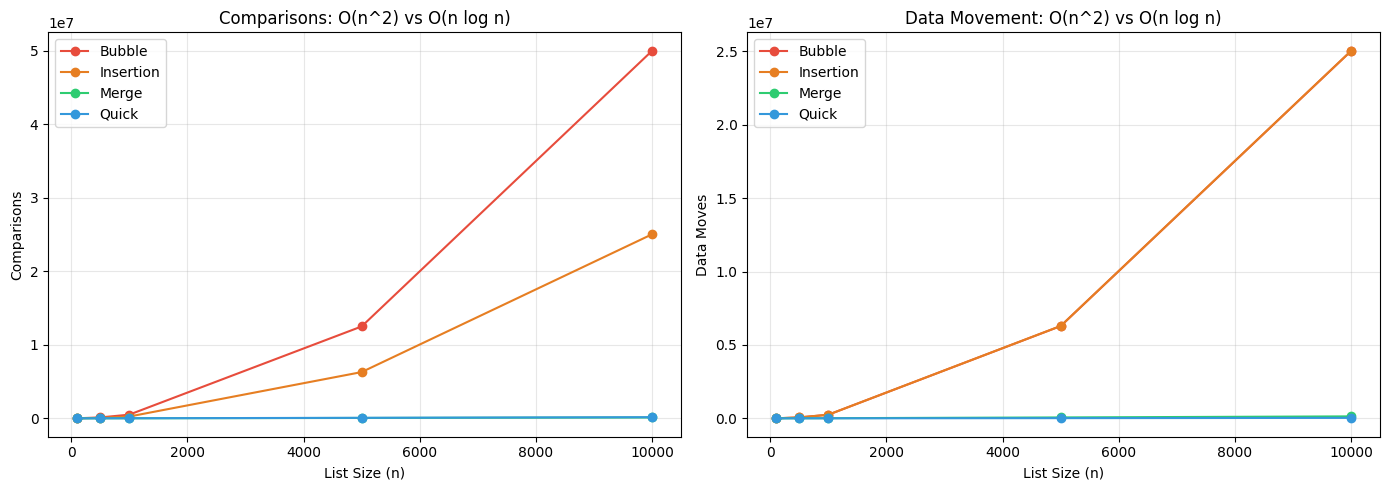

In [9]:
colors = {"Bubble": "#e74c3c", "Insertion": "#e67e22",
          "Merge": "#2ecc71", "Quick": "#3498db"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Comparisons
for name in results:
    ax1.plot(sizes, results[name]["comps"], 'o-',
             label=name, color=colors[name])
ax1.set_xlabel('List Size (n)')
ax1.set_ylabel('Comparisons')
ax1.set_title('Comparisons: O(n^2) vs O(n log n)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Data moves
for name in results:
    ax2.plot(sizes, results[name]["moves"], 'o-',
             label=name, color=colors[name])
ax2.set_xlabel('List Size (n)')
ax2.set_ylabel('Data Moves')
ax2.set_title('Data Movement: O(n^2) vs O(n log n)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Experiment 2 Questions

**Q1:** At what list size do the O(n^2) and O(n log n) curves visibly diverge? Is the separation gradual or does it suddenly explode?

*Your answer: at about 5,000 elements. it is not too sharp of an incline for bubble and insertion, more gradual.


**Q2:** At n = 10,000, roughly how many times more comparisons does bubble sort make than merge sort? Than quicksort?

Your answer: it does 5 times more than quick sort and around double the amount compared to insertion


**Q3:** Shell sort isn't shown on this graph (it doesn't have a counted version). Based on what you know about its complexity — between O(n) and O(n^2) — where would you expect it to fall? Closer to the red/orange lines or the green/blue lines?

*Your answer: I think it would fall closer to the green/blue jsut becasue it is not going to grow nearly as fast as the n^2 ones

---
## Experiment 3: Quicksort's Achilles Heel

Merge sort is O(n log n) in **all** cases. Quicksort is O(n log n) on **average** but O(n^2) in the **worst** case. Let's find that worst case.

In [16]:
import random
import matplotlib.pyplot as plt
import sys

n = 1000

# Temporarily increase the recursion limit to accommodate worst-case quicksort for n=1000
# Python's default is often 1000. We need at least n levels for a worst-case quicksort.
original_recursion_limit = sys.getrecursionlimit()
sys.setrecursionlimit(max(original_recursion_limit, n + 100))

already_sorted = list(range(n))
reverse_sorted = list(range(n - 1, -1, -1))
random_list = list(range(n))
random.shuffle(random_list)

cases = {
    "Already sorted": already_sorted,
    "Reverse sorted": reverse_sorted,
    "Random": random_list,
}

print(f"{'Case':<20} {'Algorithm':<12} {'Comparisons':>12} {'Data Moves':>12}")
print("-" * 60)

for case_name, data in cases.items():
    _, mc, mm = merge_sort_counted(data[:])
    _, qc, qe = quick_sort_counted(data[:])
    print(f"{case_name:<20} {'Merge':<12} {mc:>12,} {mm:>12,}")
    print(f"{'' :<20} {'Quick':<12} {qc:>12,} {qe:>12,}")
    if case_name != "Random":
        print()
    else:
        print()

# Reset recursion limit to original value after the experiment
sys.setrecursionlimit(original_recursion_limit)


Case                 Algorithm     Comparisons   Data Moves
------------------------------------------------------------
Already sorted       Merge               4,932        9,976
                     Quick             499,500          999

Reverse sorted       Merge               5,044        9,976
                     Quick             499,500          999

Random               Merge               8,728        9,976
                     Quick              12,562        2,280



### Experiment 3 Questions

**Q1:** On random input, which makes fewer comparisons — merge sort or quicksort? Are they in the same ballpark?

*Your answer: They are similar! quick does a lot less comparisons but seems pretty on par with each other.


**Q2:** On already-sorted input, what happens to quicksort's comparison count compared to random input? How does it compare to merge sort on the same input?

*Your answer: it drops dramaticlly! whereas merge sort doesn't move!


**Q3:** Why does sorted input cause quicksort's worst case? Think about what happens when the pivot (first item) is always the smallest value — what do the partitions look like? How many levels of recursion do you get?

*Your answer: it's because when you only use one main list so it has to go thorugh so much.


**Q4:** Given this weakness, why would anyone use quicksort instead of merge sort? Think about the data moves column — what does "in-place" mean for memory when sorting a list of 10 million items?

*Your answer: because on more simplistic items, it work so much more effecient